## Purpose
This notebook will identify only positive increase in last 3 months

In [70]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import datetime
from IPython.display import display, clear_output, HTML

In [71]:
config = configparser.ConfigParser()
config.read(os.path.join(os.path.dirname(os.path.abspath("__file__")), '../conf/config.ini'))
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [72]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [73]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [74]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 90)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter((col("Symbol").isin(['SKY']))) #| (col("Symbol") == 'PANW')
#filtered_df = filtered_df.filter(col("Date").isin(["2024-09-03","2024-08-02","2024-08-05","2024-08-30",
#                                                "2024-07-01","2024-07-02","2024-07-31",
#                                               "2024-06-28","2024-06-05","2024-06-03",
#                                               "2024-05-31","2024-05-30","2024-05-01"]))
# Show the result
filtered_df.show(2, truncate=False)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change      |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|2024-11-12|224.5500030517578 |225.58999633789062|223.36000061035156|224.22999572753906|224.22999572753906|40398300|AAPL  |0.0               |
|2024-11-12|176.00999450683594|176.6300048828125 |171.02999877929688|171.08999633789062|171.08999633789062|10557000|ABBV  |-3.339996337890625|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
only showing top 2 rows



In [75]:
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = filtered_df.select("date","symbol","close").toPandas()
# Convert all column headers to lowercase
pandas_df.columns = pandas_df.columns.str.lower()
pandas_df['date'] = pd.to_datetime(pandas_df['date'])
pandas_df['close'] = pd.to_numeric(pandas_df['close'], errors='coerce')
df = pandas_df.dropna(subset=['close'])
# Display the Pandas DataFrame
#print(pandas_df)
# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

# Create a 'year_month' column
df['year_month'] = df['date'].dt.to_period('M')

# Sort the DataFrame by 'symbol' and 'date'
# Get the current date
current_date = datetime.datetime.now()
current_year_month = pd.Period(current_date, freq='M')

print(f"current_year_month : {current_year_month}")

current_year_month : 2025-02


In [76]:
#Prepare the data for all stocks and calculate the monthly price


# Function to get first and last rows, handling current month specially
def get_first_last(group):
    group = group.sort_values('date')
    if len(group) == 1 and group['year_month'].iloc[0] == current_year_month:
        return pd.Series({
            'month_start_price': float('nan'),  # We'll fill this later
            'month_end_price': group['close'].iloc[0],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[0],
            'is_current_month': True
        })
    else:
        return pd.Series({
            'month_start_price': group['close'].iloc[0],
            'month_end_price': group['close'].iloc[-1],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[-1],
            'is_current_month': group['year_month'].iloc[0] == current_year_month
        })

# Calculate the monthly price data
monthly_data = df.groupby(by=['symbol', 'year_month'], group_keys=False).apply(get_first_last).reset_index()
#monthly_data = df.groupby(['symbol', 'year_month'], observed=False).apply(get_first_last).reset_index(drop=True)



# Sort the monthly data by symbol and year_month
monthly_data = monthly_data.sort_values(['symbol', 'year_month'])

# Fill in the start price for the current month if it's NaN
for symbol in monthly_data['symbol'].unique():
    symbol_data = monthly_data[monthly_data['symbol'] == symbol]
    current_month_row = symbol_data[symbol_data['is_current_month'] & symbol_data['month_start_price'].isna()]
    
    if not current_month_row.empty:
        prev_month_row = symbol_data[symbol_data['year_month'] < current_year_month].iloc[-1] if len(symbol_data) > 1 else None
        if prev_month_row is not None:
            monthly_data.loc[current_month_row.index, 'month_start_price'] = prev_month_row['month_end_price']

# Calculate the price increase
monthly_data['monthly_increase'] = monthly_data['month_end_price'] - monthly_data['month_start_price']

# Calculate the percentage increase
monthly_data['monthly_increase_percent'] = (monthly_data['monthly_increase'] / monthly_data['month_start_price']) * 100

# Merge the calculated monthly increase back into the original DataFrame
df = df.merge(
    monthly_data[['symbol', 'year_month', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']],
    on=['symbol', 'year_month'],
    how='left'
)

# Clean up
df = df.drop('year_month', axis=1)

# Set 'date' as index if desired
df = df.set_index('date')

# Display the results
#print(df[['symbol', 'close', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']].head(10))

# Optional: If you want to see the monthly increase for each month
print("\nMonthly increase for each month:")
print(monthly_data[['symbol', 'year_month', 'month_start_date', 'month_end_date', 'month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent', 'is_current_month']].head(10))


Monthly increase for each month:
  symbol year_month month_start_date month_end_date  month_start_price  \
0   AAPL    2024-11       2024-11-12     2024-11-29         224.229996   
1   AAPL    2024-12       2024-12-02     2024-12-31         239.589996   
2   AAPL    2025-01       2025-01-02     2025-01-31         243.850006   
3   AAPL    2025-02       2025-02-03     2025-02-07         228.009995   
4   ABBV    2024-11       2024-11-12     2024-11-29         171.089996   
5   ABBV    2024-12       2024-12-02     2024-12-31         181.770004   
6   ABBV    2025-01       2025-01-02     2025-01-31         179.440002   
7   ABBV    2025-02       2025-02-03     2025-02-07         190.139999   
8    ACB    2024-11       2024-11-12     2024-11-29           4.730000   
9    ACB    2024-12       2024-12-02     2024-12-31           4.630000   

   month_end_price  monthly_increase  monthly_increase_percent  \
0       237.330002         13.100006                  5.842218   
1       250.419998 

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_37489/3400307910.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_data = df.groupby(by=['symbol', 'year_month'], group_keys=False).apply(get_first_last).reset_index()


In [77]:
# Step 6: Filter the dataframe for the top 25 symbols based on 3-month increases
# For demonstration purposes, we'll consider 'monthly_increase' over the last 3 months.

# Get the current date and calculate the date 3 months ago
current_date = datetime.datetime.now()
three_months_ago = current_date - pd.DateOffset(months=4)

# Filter the monthly data for the last 3 months
last_3_months_data = monthly_data[monthly_data['month_end_date'] > three_months_ago]

# Function to check if a stock has consistently increased in the last 3 months
def check_consistent_increase(group):
    # Exclude the current month and check the previous 3 months
    #last_3_months = group.iloc[-4:-1]
    last_3_months = group.tail(3)  # Get the last 3 available months
    return (last_3_months['monthly_increase'] > 0).all()

# Group by symbol and apply the check_consistent_increase function
consistent_increase = last_3_months_data.groupby('symbol').apply(check_consistent_increase)


# Group by symbol and check if monthly_increase is positive for the last 3 months
#consistent_increase = last_3_months_data.groupby('symbol',group_keys=False).apply(
#    lambda x: (x['monthly_increase'].tail(4).head(3) > 0).all()
#)
#print(consistent_increase)
# Filter the original dataframe to include only the stocks with consistent increase
consistent_df = last_3_months_data[last_3_months_data['symbol'].isin(consistent_increase[consistent_increase].index)]

# Display the results
print(consistent_df[['symbol', 'year_month', 'monthly_increase']])



    symbol year_month  monthly_increase
43    AMBA    2024-11         11.840004
44    AMBA    2024-12          2.570000
45    AMBA    2025-01          2.620003
46    AMBA    2025-02          0.410004
79    APPS    2024-11          0.080000
..     ...        ...               ...
757   TRIP    2025-02          1.020000
807   WDAY    2024-11        -20.330002
808   WDAY    2024-12          6.569992
809   WDAY    2025-01         10.220001
810   WDAY    2025-02         12.120026

[80 rows x 3 columns]


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_37489/93245449.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  consistent_increase = last_3_months_data.groupby('symbol').apply(check_consistent_increase)


In [78]:
# Calculate the cumulative 3-month increase for each symbol
cumulative_increase = consistent_df.groupby('symbol').agg({
    'monthly_increase': 'sum',
    'month_start_price': 'first',
    'month_end_price': 'last'
}).reset_index()

cumulative_increase['cumulative_percent_increase'] = (
    (cumulative_increase['month_end_price'] - cumulative_increase['month_start_price']) / 
    cumulative_increase['month_start_price'] * 100
)

# Sort by cumulative percent increase and get the top 25 symbols
top_25_symbols = cumulative_increase.sort_values('cumulative_percent_increase', ascending=False).head(25)

# Filter the original dataframe for these top 25 symbols
df_top_25 = consistent_df[consistent_df['symbol'].isin(top_25_symbols['symbol'])]

# Display the results
print("Top 25 Symbols Based on 3-Month Increase:")
print(top_25_symbols[['symbol', 'cumulative_percent_increase']])

print("\nSample of filtered dataframe (first 10 rows):")
print(df_top_25[['symbol', 'month_start_date','month_end_date','month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent']].head(10))

best_25_df_for_table_display = df_top_25[['symbol', 'month_start_date','month_end_date','month_start_price', 'month_end_price', 'monthly_increase']]
# Optional: Save the filtered dataframe to a CSV file
#df_top_25.to_csv('top_25_symbols_3_month_increase.csv', index=True)
#print("\nFiltered dataframe saved to 'top_25_symbols_3_month_increase.csv'")

Top 25 Symbols Based on 3-Month Increase:
   symbol  cumulative_percent_increase
5    CRNC                   329.673592
1    APPS                   260.294121
17   SENS                   230.158721
15     RR                   223.377966
2      BB                   116.942142
12   PLBY                    94.444428
13   PLTR                    85.213035
10    NET                    83.324163
4     CLS                    54.294552
9    MVIS                    52.525250
18   TATT                    42.829361
14   QFIN                    40.045614
19   TRIP                    28.260874
0    AMBA                    26.812933
6     DDD                    25.588231
16    SAP                    19.264730
7    DRIP                     9.368637
11   PETS                     2.901356
8     MRO                     0.812145
20   WDAY                     0.580796
3     BDL                    -0.394479

Sample of filtered dataframe (first 10 rows):
    symbol month_start_date month_end_date  month_sta

In [79]:
# Create a dropdown widget for symbol selection
symbols = ['All'] + list(best_25_df_for_table_display['symbol'].unique())
symbol_dropdown = widgets.Dropdown(options=symbols, description='Symbol:', value='All')

# Function to create HTML table
def create_html_table(selected_symbol):
    if selected_symbol != 'All':
        filtered_df = best_25_df_for_table_display[best_25_df_for_table_display['symbol'] == selected_symbol]
    else:
        filtered_df = best_25_df_for_table_display
    
    # Create HTML table
    html_table = '<table style="border-collapse: collapse; width: 100%;">'
    html_table += '<tr style="background-color: #f2f2f2;">'
    for col in filtered_df.columns:
        html_table += f'<th style="border: 1px solid #ddd; padding: 8px; text-align: left;">{col}</th>'
    html_table += '</tr>'
    
    for _, row in filtered_df.iterrows():
        html_table += '<tr>'
        for i, value in enumerate(row):
            if i == 5:  # Monthly Increase column
                color = 'green' if value > 0 else 'red'
                html_table += f'<td style="border: 1px solid #ddd; padding: 8px; color: {color};">{value:.2f}</td>'
            elif i in [3, 4]:  # Price columns
                html_table += f'<td style="border: 1px solid #ddd; padding: 8px;">{value:.2f}</td>'
            else:
                html_table += f'<td style="border: 1px solid #ddd; padding: 8px;">{value}</td>'
        html_table += '</tr>'
    
    html_table += '</table>'
    return html_table

# Output widget to display the table
output = widgets.Output()

# Function to update the output
def update_output(change):
    with output:
        output.clear_output(wait=True)
        display(HTML(create_html_table(change['new'])))

# Attach the function to the dropdown's value trait
symbol_dropdown.observe(update_output, names='value')

# Display the dropdown and the initial table
display(symbol_dropdown, output)

# Show the initial 'All' table
with output:
    display(HTML(create_html_table('All')))

Dropdown(description='Symbol:', options=('All', 'AMBA', 'APPS', 'BB', 'BDL', 'CLS', 'CRNC', 'DDD', 'DRIP', 'MR…

Output()

In [80]:
# Convert 'date' to datetime format and create a 'year_month' column for grouping
df = df_top_25
df['month_start_date'] = pd.to_datetime(df['month_start_date'])
df['year_month'] = df['month_start_date'].dt.to_period('M')

# Convert 'year_month' to string for proper ordering in plot
df['year_month_str'] = df['year_month'].astype(str)

# Fill NaN values
df['monthly_increase'] = df['monthly_increase'].fillna(0.0)

# Ensure 'year_month_str' is treated as categorical with a specific order
df['year_month_str'] = pd.Categorical(df['year_month_str'], categories=sorted(df['year_month_str'].unique()), ordered=True)

# Aggregate data
agg_df = df.groupby(['year_month_str', 'symbol'], observed=False).agg(
    total_monthly_increase=('monthly_increase', 'sum'),
    avg_percentage_increase=('monthly_increase_percent', 'mean')
).reset_index()

# Fill NaN values with 0 in 'monthly_increase' and 'percentage_increase'
agg_df['total_monthly_increase'] = agg_df['total_monthly_increase'].fillna(0)
agg_df['avg_percentage_increase'] = agg_df['avg_percentage_increase'].fillna(0)
agg_df = agg_df[agg_df['total_monthly_increase'] > 0]
print(agg_df)

   year_month_str symbol  total_monthly_increase  avg_percentage_increase
0         2024-11   AMBA               11.840004                19.829181
1         2024-11   APPS                0.080000                 5.882356
2         2024-11     BB                0.150000                 6.198341
4         2024-11    CLS                1.180000                 1.403760
5         2024-11   CRNC                3.995000               118.545995
..            ...    ...                     ...                      ...
79        2025-02    SAP                7.080017                 2.597599
80        2025-02   SENS                0.145000                16.201116
81        2025-02   TATT                0.879999                 3.087716
82        2025-02   TRIP                1.020000                 5.906198
83        2025-02   WDAY               12.120026                 4.665676

[73 rows x 4 columns]


In [81]:


#print(agg_df)
# Group the data by symbol and month, then calculate the mean percentage increase
grouped = agg_df.groupby(['symbol', 'year_month_str'],observed=False)['avg_percentage_increase'].mean().unstack()

# Fill NaN values with 0
grouped = grouped.fillna(0)

# Calculate the overall percentage increase for each symbol
overall_increase = grouped.sum(axis=1)

#print(grouped)
# Sort the DataFrame by the total percentage increase (sum across all months)
#sorted_df = grouped.sort_values(by=grouped.columns.tolist(), ascending=True)
sorted_df = grouped.loc[overall_increase.sort_values().index]
print(sorted_df)

year_month_str     2024-11     2024-12     2025-01    2025-02
symbol                                                       
MRO               0.812145    0.000000    0.000000   0.000000
BDL               0.000000    2.020202    1.097563   2.558892
WDAY              0.000000    2.612738    4.058133   4.665676
DRIP              0.000000   15.957447    1.431303   0.561793
PETS              0.000000    5.470459    2.586215  10.602915
SAP               1.334928    1.912335   13.548866   2.597599
TRIP              0.490881    2.285325   17.144761   5.906198
AMBA             19.829181    3.662534    3.535766   0.544421
QFIN             24.177256    6.080710    3.127431   7.584477
DDD               0.000000   17.562725   12.499995  14.171122
TATT             10.743807   13.628318   17.662238   3.087716
CLS               1.403760    8.639364   32.663588   7.296492
NET               9.811899    2.503567   22.978490  21.791880
PLTR             12.080206   13.917756    9.708731  32.374016
MVIS    

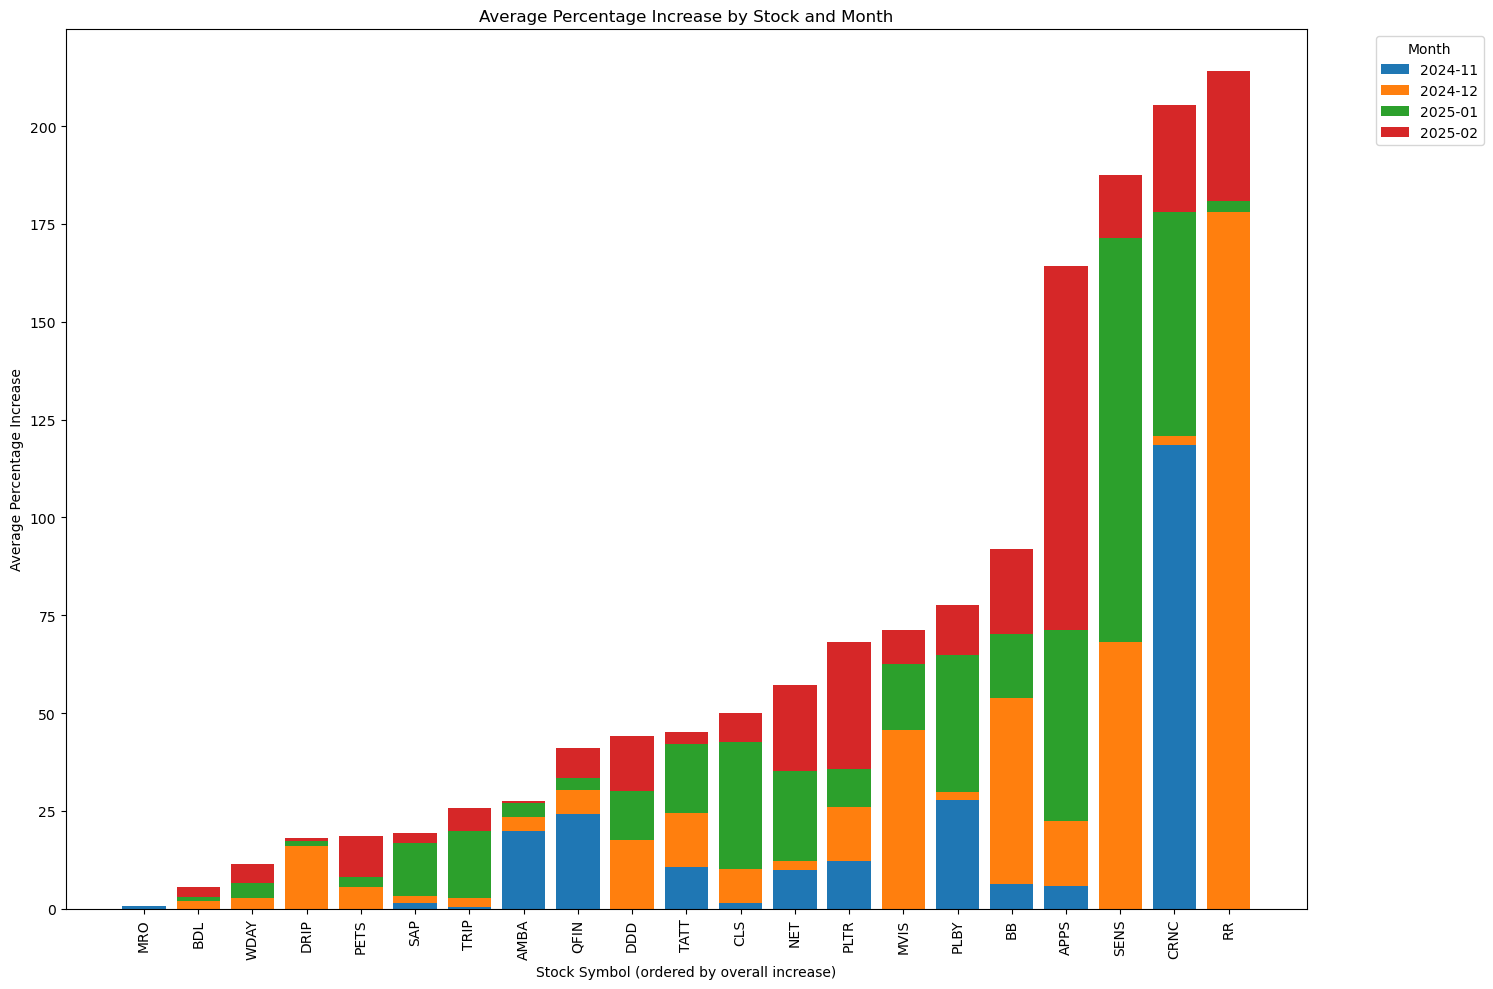

In [82]:
# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(15, 10))

bottom = np.zeros(len(sorted_df))

for month in sorted_df.columns:
    ax.bar(sorted_df.index, sorted_df[month], bottom=bottom, label=month)
    bottom += sorted_df[month]

# Customize the chart
ax.set_title('Average Percentage Increase by Stock and Month')
ax.set_xlabel('Stock Symbol (ordered by overall increase)')
ax.set_ylabel('Average Percentage Increase')
ax.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

In [83]:
# Ensure current_year_month is defined (for example, '2024-06')
print(current_year_month)

# Filter the DataFrame for the current year and month
cr_mnth_inc_df = agg_df[agg_df["year_month_str"] == current_year_month].copy()
# Reset the index to start from 0 and drop the old index
cr_mnth_inc_df = cr_mnth_inc_df.reset_index(drop=True)

# Print the filtered DataFrame

print(cr_mnth_inc_df)


2025-02
Empty DataFrame
Columns: [year_month_str, symbol, total_monthly_increase, avg_percentage_increase]
Index: []


In [84]:
# Get the last two months
last_two_months = best_25_df_for_table_display['month_start_date'].max() - pd.DateOffset(months=2)
print(f"last_two_months : {last_two_months}")
last_two_months = pd.date_range(start=last_two_months, end=best_25_df_for_table_display['month_start_date'].max(), freq='MS').strftime('%Y-%m')
print(f"last_two_months : {last_two_months}")

# Filter the DataFrame for the last two months and make a copy
ltmonths_df = best_25_df_for_table_display[best_25_df_for_table_display['month_start_date'].dt.to_period('M').astype(str).isin(last_two_months)].copy()

# Create a 'month' column for plotting
ltmonths_df['month'] = ltmonths_df['month_start_date'].dt.to_period('M').astype(str)

print(ltmonths_df)

last_two_months : 2024-12-03 00:00:00
last_two_months : Index(['2025-01', '2025-02'], dtype='object')
    symbol month_start_date month_end_date  month_start_price  \
45    AMBA       2025-01-02     2025-01-31          74.099998   
46    AMBA       2025-02-03     2025-02-07          75.309998   
81    APPS       2025-01-02     2025-01-31           1.760000   
82    APPS       2025-02-03     2025-02-07           2.540000   
101     BB       2025-01-02     2025-01-31           3.820000   
102     BB       2025-02-03     2025-02-07           4.310000   
109    BDL       2025-01-02     2025-01-31          24.600000   
110    BDL       2025-02-03     2025-02-07          24.620001   
177    CLS       2025-01-02     2025-01-31          93.070000   
178    CLS       2025-02-03     2025-02-07         120.879997   
201   CRNC       2025-01-02     2025-01-31           7.930000   
202   CRNC       2025-02-03     2025-02-07          11.370000   
237    DDD       2025-01-02     2025-01-31           

In [85]:
print(ltmonths_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 45 to 810
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   symbol             40 non-null     object        
 1   month_start_date   40 non-null     datetime64[ns]
 2   month_end_date     40 non-null     datetime64[ns]
 3   month_start_price  40 non-null     float64       
 4   month_end_price    40 non-null     float64       
 5   monthly_increase   40 non-null     float64       
 6   month              40 non-null     object        
dtypes: datetime64[ns](2), float64(3), object(2)
memory usage: 2.5+ KB
None


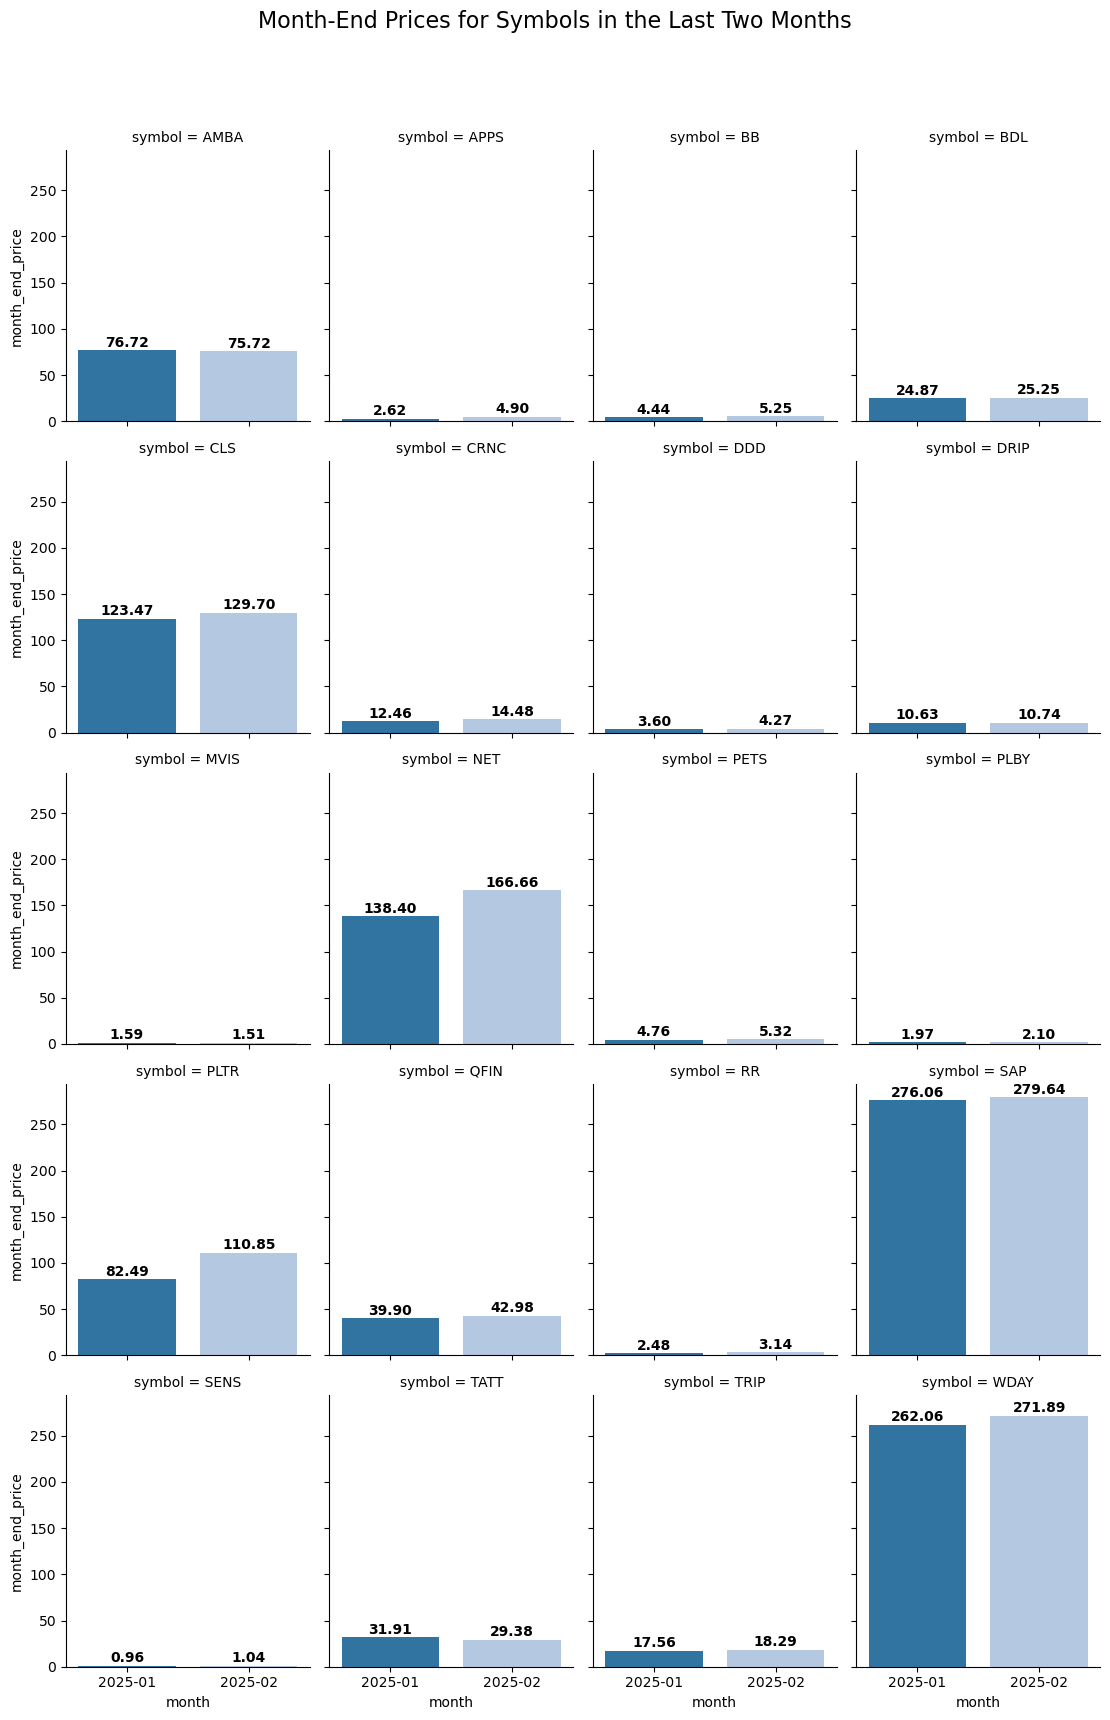

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
# Ensure 'month' is categorical for proper ordering
ltmonths_df["month"] = pd.Categorical(ltmonths_df["month"], ordered=True)

# Plot
# Plot using catplot
g = sns.catplot(x="month", y="month_end_price", col="symbol", hue="month", col_wrap=4,
                data=ltmonths_df,
                kind="bar", height=3.5, aspect=.8, 
                palette='tab20')

# Display actual values on top of bars
for ax in g.axes.flat:
    for p in ax.patches:  # Iterate over each bar
        height = p.get_height()  # Get the height of the bar
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5,  # Position text slightly above the bar
                f'{height:.2f}',  # Display value with two decimal places
                ha='center', va='bottom', fontsize=10, fontweight='bold')  # Center text

# Set a more descriptive title
g.fig.suptitle('Month-End Prices for Symbols in the Last Two Months', fontsize=16)

# Adjust the layout to prevent title overlap
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust this value as needed

plt.show()